**Scaling**

- We have two types of scaling

  - Z score (Standardization)

  - Min max scalar (Normalization)

**Z score**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path=r"C:\Users\91801\Documents\Data_Files\Visadataset.csv"
visa_df=pd.read_csv(file_path)
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [4]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [5]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [6]:
num


Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [7]:
# step-1: take the pwage data
# step-2: calculate mean of the data
# step-3: calculate std of the data
# step-4: Nr =data-mean step1-step-2
# step-5: z_Wage=Nr/std=Step4/Step3

wage_data=visa_df['prevailing_wage']
wage_Mean=wage_data.mean()
wage_std=wage_data.std()
Nr=wage_data-wage_Mean
z_wage=Nr/wage_std
visa_df['z_wage']=z_wage

In [8]:
z_wage

0       -1.398510
1        0.169832
2        0.919060
3        0.169991
4        1.428576
           ...   
25475    0.049923
25476    3.876083
25477    1.360253
25478    0.221504
25479   -0.067762
Name: prevailing_wage, Length: 25480, dtype: float64

In [9]:
visa_df[['prevailing_wage','z_wage']]

,prevailing_wage,z_wage
0,592.2029,-1.398510
1,83425.6500,0.169832
2,122996.8600,0.919060
3,83434.0300,0.169991
4,149907.3900,1.428576
...,...,...
25475,77092.5700,0.049923
25476,279174.7900,3.876083
25477,146298.8500,1.360253
25478,86154.7700,0.221504


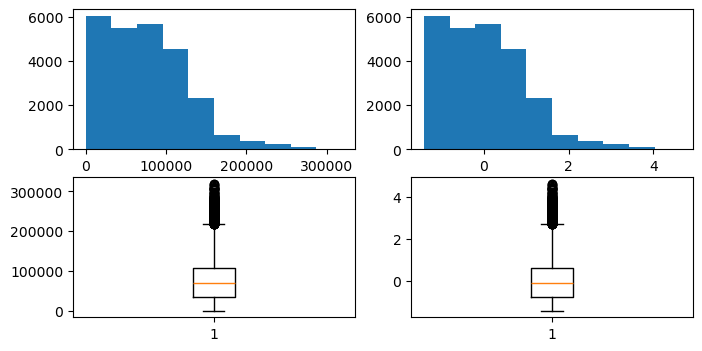

In [10]:
plt.figure(figsize=(8,4))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(z_wage)
plt.subplot(2,2,3).boxplot(wage_data)
plt.subplot(2,2,4).boxplot(z_wage)
plt.show()

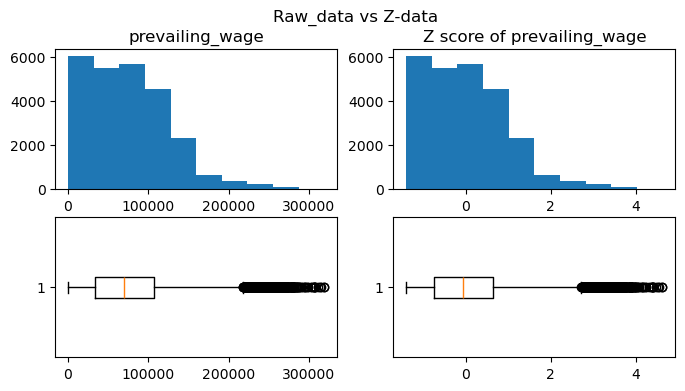

In [11]:
plt.figure(figsize=(8,4))
plt.suptitle('Raw_data vs Z-data')
plt.subplot(2,2,1).hist(wage_data)
plt.title('prevailing_wage')
plt.subplot(2,2,2).hist(z_wage)
plt.title('Z score of prevailing_wage')
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(z_wage,vert=False)
plt.show()

**StandardScalar**

- sklearn

   - preprocessing

     - StandardScalar

In [23]:
# step-1: import method
# step-2: save the method
# Step-3: apply fit transform

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
wage_ss=ss.fit_transform(visa_df[['prevailing_wage']])
visa_df['wage_ss']=wage_ss
wage_ss

array([[-1.39853722],
       [ 0.1698353 ],
       [ 0.91907852],
       ...,
       [ 1.36027953],
       [ 0.22150859],
       [-0.06776315]])

In [20]:
visa_df['prevailing_wage']  #---> series 1D

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [21]:
visa_df[['prevailing_wage']]  #-->dataframe double square brackets 2D

,prevailing_wage
0,592.2029
1,83425.6500
2,122996.8600
3,83434.0300
4,149907.3900
...,...
25475,77092.5700
25476,279174.7900
25477,146298.8500
25478,86154.7700


In [24]:
visa_df[['prevailing_wage','z_wage','wage_ss']]
# manual data name is 'z_wage' and python code package name is 'wage_ss' and in the o/p they are same so 
# we did it correctly

,prevailing_wage,z_wage,wage_ss
0,592.2029,-1.398510,-1.398537
1,83425.6500,0.169832,0.169835
2,122996.8600,0.919060,0.919079
3,83434.0300,0.169991,0.169994
4,149907.3900,1.428576,1.428604
...,...,...,...
25475,77092.5700,0.049923,0.049924
25476,279174.7900,3.876083,3.876159
25477,146298.8500,1.360253,1.360280
25478,86154.7700,0.221504,0.221509


In [27]:
visa_df  # complete data in visa data
visa_df['prevailing_wage'] # we are selecting one column -->series
visa_df['prevailing_wage'].values  # selecting only values from wages
visa_df[['prevailing_wage']] # dataframe

,prevailing_wage
0,592.2029
1,83425.6500
2,122996.8600
3,83434.0300
4,149907.3900
...,...
25475,77092.5700
25476,279174.7900
25477,146298.8500
25478,86154.7700


In [33]:
visa_df
visa_df['prevailing_wage']
#visa_df['prevailing_wage'].reshape() # attributeerror
visa_df['prevailing_wage'].values
visa_df['prevailing_wage'].values.reshape(-1,1)

array([[   592.2029],
       [ 83425.65  ],
       [122996.86  ],
       ...,
       [146298.85  ],
       [ 86154.77  ],
       [ 70876.91  ]])

In [34]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
wage_ss=ss.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))
wage_ss

array([[-1.39853722],
       [ 0.1698353 ],
       [ 0.91907852],
       ...,
       [ 1.36027953],
       [ 0.22150859],
       [-0.06776315]])

**MinMaxScalar**

<img src="https://miro.medium.com/v2/resize:fit:888/1*ye1I00S61GqpR34ABZZFLQ.png" jsaction="" class="sFlh5c FyHeAf iPVvYb" style="max-width: 444px; height: 107px; margin: 19.5px 0px; width: 305px;" alt="How Min-Max Scaler Works. The math behind the min-max scaler | by Kamlesh  Kumar Rangi | Medium" jsname="kn3ccd">

In [36]:
# steps to copy image from google
# go to google type min max scalar
# open image formula right click click on inspect -->image src 
# right click edit as html ctrl+c
# go to jupyter ctrl+v 
#               esc+m 
#               shift+enter the formula comes here like above

In [37]:
# step-1: read the data
# step-2: calculate min
# step-3: calculate max
# step-4: Nr=step1-step2
# step-5: Dr=step3-step2
# step-6: Nr/Dr
# step-7: visa_df['wage_min_max']=Nr/Dr

In [44]:
# using python code
wage_data=visa_df['prevailing_wage']
wage_data_min=wage_data.min()
wage_data_max=wage_data.max()
Nr=wage_data-wage_data_min
Dr=wage_data_max-wage_data_min
Nr/Dr
max(Nr/Dr),min(Nr/Dr)

(1.0, 0.0)

In [46]:
# using package
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
mms.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))


array([[0.00184853],
       [0.2613452 ],
       [0.385312  ],
       ...,
       [0.45831136],
       [0.26989486],
       [0.22203311]])